In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
from pathlib import Path
import numpy as np

# Directory paths for train, validation, and test sets
dataset = Path('/content/drive/MyDrive/Bone_Fracture_Dataset')
train_dir = '/content/drive/MyDrive/Bone_Fracture_Dataset/train'
val_dir = '/content/drive/MyDrive/Bone_Fracture_Dataset/val'
test_dir = '/content/drive/MyDrive/Bone_Fracture_Dataset/test'

# Image dimensions
img_height = 224
img_width = 224
RANDOM_SEED = 42

In [ ]:
# Image dimensions
img_height = 224
img_width = 224
RANDOM_SEED = 42
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.convnext import preprocess_input

IMG_SIZE = 224

# Custom preprocessing function for MobileNetV2
def convnext_preprocess(img):
    return preprocess_input(img)  # Converts to [-1, 1]

# ImageDataGenerator for data augmentation and correct normalization
datagen = ImageDataGenerator(
    preprocessing_function=convnext_preprocess,  # Use convnext preprocessing
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
def walk_dir(dataset):
    for dirpath, dirnames, filenames in os.walk(dataset):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_dir(dataset)

There are 3 directories and 0 images in '/content/drive/MyDrive/Bone_Fracture_Dataset'.
There are 2 directories and 0 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/test'.
There are 0 directories and 239 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/test/fractured'.
There are 0 directories and 263 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/test/not fractured'.
There are 2 directories and 0 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/train'.
There are 0 directories and 4635 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/train/not fractured'.
There are 0 directories and 4607 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/train/fractured'.
There are 2 directories and 0 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/val'.
There are 0 directories and 487 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/val/not fractured'.
There are 0 directories and 338 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/val/f

In [ ]:
import cv2
import numpy as np

def apply_clahe(image):
    if len(image.shape) == 3 and image.shape[2] == 3:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        image_gray = image
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(image_gray)

array([[128, 111,  93, ...,  56,  65,  81],
       [134, 116,  99, ...,  54,  62,  81],
       [128, 122, 122, ...,  54,  62,  81],
       ...,
       [128, 115, 107, ...,  47,  63,  74],
       [133, 122, 111, ...,  52,  68,  78],
       [136, 130, 118, ...,  65,  71,  82]], dtype=uint8)
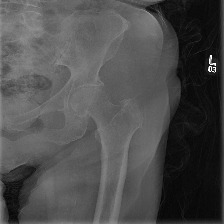

In [ ]:
IMG_SIZE = 224

def get_Image():
    image_path_list = list(dataset.glob("*/*/*.*"))
    sample_path = image_path_list[0]
    img = cv2.imread(str(sample_path))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = apply_clahe(img)
    return sample_path.name, img
_, img = get_Image()
img

<Figure size 1000x1000 with 0 Axes>

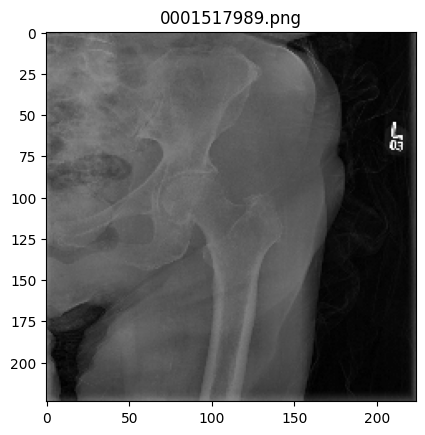

<Figure size 1000x1000 with 0 Axes>

In [ ]:
title, img = get_Image()
img_arr = np.asarray(img)

plt.imshow(img_arr, cmap='gray') #Always show black and white images
plt.title(title)
plt.figure(figsize=(10,10))

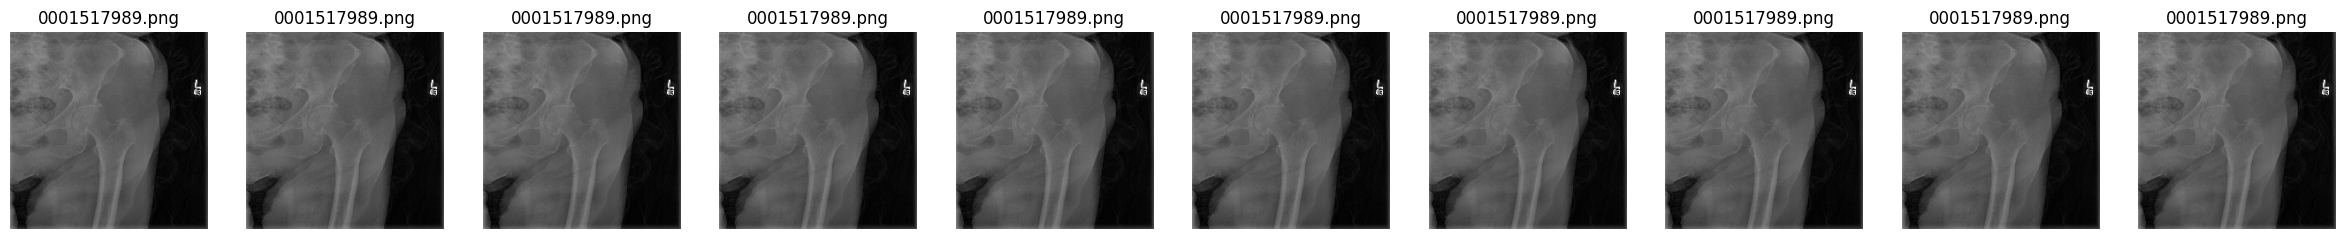

In [ ]:
def Show_Images(n_img):
    fig, axes = plt.subplots(1, n_img, figsize=(30, 20))
    axes = axes.flatten()  # Flatten axes for easy indexing

    # Loop through images and display them
    for i in range(n_img):
        title, img = get_Image()
        img = np.asarray(img)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(title)
        axes[i].axis("off")  # Hide axes
Show_Images(10)

In [ ]:
# Training data generator
train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=16,
    class_mode='binary'  # Use 'binary' for string labels (one-hot encoding)
)


# Validation data generator
val_gen = datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=16,
    class_mode='binary'  # Use 'binary' for string labels (one-hot encoding)
)

# Test data generator
test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=16,
    class_mode='binary'  # Use 'binary' for string labels (one-hot encoding)
)

Found 9240 images belonging to 2 classes.
Found 823 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
class StopAtAccuracy(Callback):
    def __init__(self, target_acc=0.99, target_loss=0.05):
        super(StopAtAccuracy, self).__init__()
        self.target_acc = target_acc
        self.target_loss = target_loss

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get("accuracy")
        loss = logs.get("loss")

        if acc is not None and loss is not None:
            if acc >= self.target_acc and loss <= self.target_loss:
                print("\n🎯 Target tercapai! Accuracy ≥ 99% dan Loss sangat kecil.")
                self.model.stop_training = True

In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ConvNeXtSmall
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout # Import necessary layers

base_model = ConvNeXtSmall(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False # Bekukan seluruh model dasar

x = base_model.output
    # Gunakan GlobalAveragePooling2D seperti saran sebelumnya
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='gelu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)

learning_rate = 0.0001 # Tingkat pembelajaran yang sedikit lebih tinggi untuk fase ini
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])



    # Latih model selama beberapa epoch (misal 10-20 epoch)
r_frozen = model.fit(train_gen, validation_data=val_gen, epochs=20, verbose=2 )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


578/578 - 4116s - 7s/step - accuracy: 0.7817 - loss: 0.4613 - val_accuracy: 0.8481 - val_loss: 0.3720
Epoch 2/20
578/578 - 134s - 231ms/step - accuracy: 0.8711 - loss: 0.3167 - val_accuracy: 0.8724 - val_loss: 0.3110
Epoch 3/20
578/578 - 134s - 231ms/step - accuracy: 0.8922 - loss: 0.2646 - val_accuracy: 0.8724 - val_loss: 0.3144
Epoch 4/20
578/578 - 134s - 232ms/step - accuracy: 0.9115 - loss: 0.2280 - val_accuracy: 0.8809 - val_loss: 0.3091
Epoch 5/20
578/578 - 133s - 230ms/step - accuracy: 0.9242 - loss: 0.2004 - val_accuracy: 0.9004 - val_loss: 0.2529
Epoch 6/20
578/578 - 133s - 230ms/step - accuracy: 0.9359 - loss: 0.1744 - val_accuracy: 0.9040 - val_loss: 0.2382
Epoch 7/20
578/578 - 133s - 231ms/step - accuracy: 0.9405 - loss: 0.1622 - val_accuracy: 0.9113 - val_loss: 0.2133
Epoch 8/20
578/578 - 133s - 231ms/step - accuracy: 0.9490 - loss: 0.1473 - val_accuracy: 0.9149 - val_loss: 0.2180
Epoch 9/20
578/578 - 133s - 230ms/step - accuracy: 0.9543 - loss: 0.1331 - val_accuracy: 0.91

In [ ]:
# Buka sebagian layer dari base_model
base_model.trainable = True
fine_tune_from = 50 # Sesuaikan nilai ini - Anda perlu mencari tahu berapa banyak layer terakhir yang ingin di-unfreeze
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False # Bekukan layer-layer awal

    # Kompilasi ulang model dengan learning rate yang sangat rendah
learning_rate = 0.00001 # Jauh lebih rendah!
optimizer = Adam(learning_rate=learning_rate) # Bisa juga gunakan optimizer lain seperti SGD dengan momentum
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # Lanjutkan pelatihan selama lebih banyak epoch (misal 40-60 epoch lagi)
    # Anda bisa melanjutkan pelatihan dari bobot yang sudah dilatih di fase 1
r_fine_tune = model.fit(train_gen, validation_data=val_gen, epochs=55, # Total epoch 60 (20 + 40)
                        initial_epoch=r_frozen.epoch[-1], # Mulai dari akhir epoch fase 1
                        verbose=2)

    # Anda bisa menggabungkan history dari kedua fase pelatihan untuk plotting

Epoch 20/55
578/578 - 268s - 463ms/step - accuracy: 0.9874 - loss: 0.0422 - val_accuracy: 0.9660 - val_loss: 0.0870
Epoch 21/55
578/578 - 141s - 243ms/step - accuracy: 0.9957 - loss: 0.0151 - val_accuracy: 0.9733 - val_loss: 0.0650
Epoch 22/55
578/578 - 140s - 242ms/step - accuracy: 0.9962 - loss: 0.0119 - val_accuracy: 0.9830 - val_loss: 0.0487
Epoch 23/55
578/578 - 139s - 241ms/step - accuracy: 0.9962 - loss: 0.0099 - val_accuracy: 0.9830 - val_loss: 0.0394
Epoch 24/55
578/578 - 139s - 241ms/step - accuracy: 0.9988 - loss: 0.0051 - val_accuracy: 0.9891 - val_loss: 0.0244
Epoch 25/55
578/578 - 140s - 243ms/step - accuracy: 0.9982 - loss: 0.0059 - val_accuracy: 0.9951 - val_loss: 0.0241
Epoch 26/55
578/578 - 141s - 243ms/step - accuracy: 0.9990 - loss: 0.0039 - val_accuracy: 0.9915 - val_loss: 0.0258
Epoch 27/55
578/578 - 140s - 243ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 0.9915 - val_loss: 0.0297
Epoch 28/55
578/578 - 140s - 243ms/step - accuracy: 0.9986 - loss: 0.004

In [ ]:
import pandas as pd
#save history
# Use the variable where the history was actually stored, e.g., r_fine_tune
hist_df = pd.DataFrame(r_fine_tune.history)
# or save to csv:
hist_csv_file = 'model_convnext_new_history.csv'
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)

#save model
model.save("convnext_lung_fixed.keras")

#save weights
model.save_weights('model_convnext_new_lung_.weights.h5')

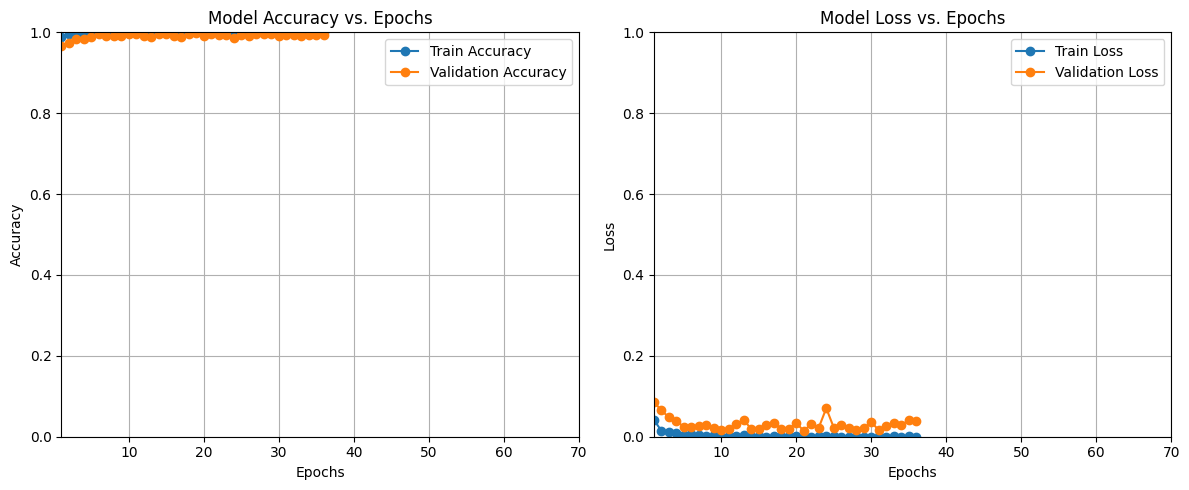

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'r_fine_tune.history' contains the training history
history = r_fine_tune.history

# Buat sumbu epoch sampai 70
epochs = range(1, 71)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs[:len(history['accuracy'])], history['accuracy'],
         label='Train Accuracy', marker='o')
plt.plot(epochs[:len(history['val_accuracy'])], history['val_accuracy'],
         label='Validation Accuracy', marker='o')
plt.title('Model Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.ylim(0.0, 1.0)
plt.xlim(1, 70)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs[:len(history['loss'])], history['loss'],
         label='Train Loss', marker='o')
plt.plot(epochs[:len(history['val_loss'])], history['val_loss'],
         label='Validation Loss', marker='o')
plt.title('Model Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.ylim(0.0, 1.0)
plt.xlim(1, 70)

plt.tight_layout()
plt.show()


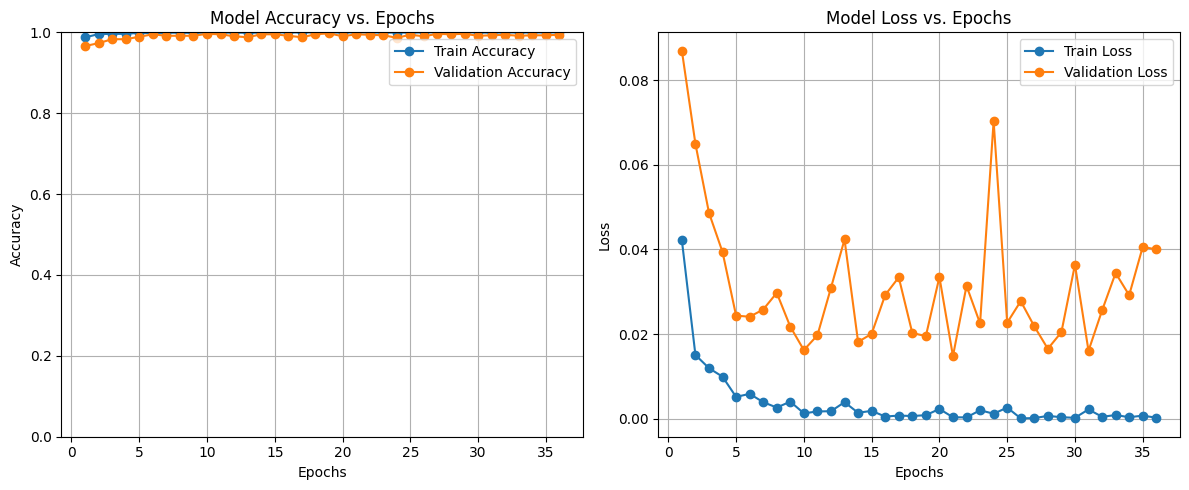

In [ ]:
import matplotlib.pyplot as plt

# Ambil history training
history = r_fine_tune.history

# Ambil jumlah epoch sebenarnya
epochs = range(1, len(history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.ylim(0.0, 1.0)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history['loss'], label='Train Loss', marker='o')
plt.plot(epochs, history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Found 500 images belonging to 2 classes.
Class Labels: ['fractured', 'not fractured']


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step
Unique predictions: (array([0, 1]), array([231, 269]))

Overall Evaluation Metrics:


,Metric,Score
0,Accuracy,0.986000
1,Precision,0.973978
2,Recall,1.000000
3,F1-Score,0.986817



Classification Report:
               precision    recall  f1-score   support

    fractured     1.0000    0.9706    0.9851       238
not fractured     0.9740    1.0000    0.9868       262

     accuracy                         0.9860       500
    macro avg     0.9870    0.9853    0.9859       500
 weighted avg     0.9864    0.9860    0.9860       500



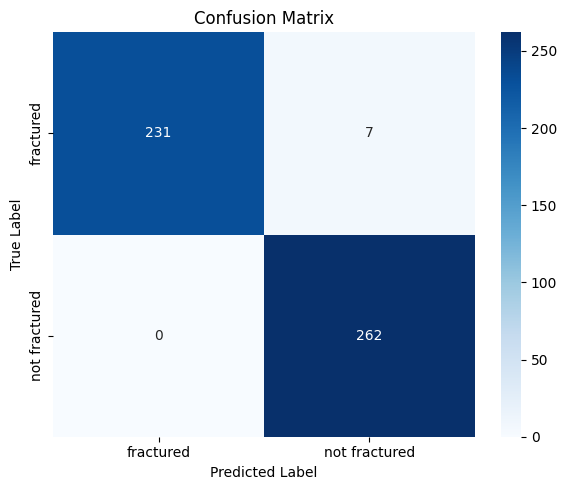

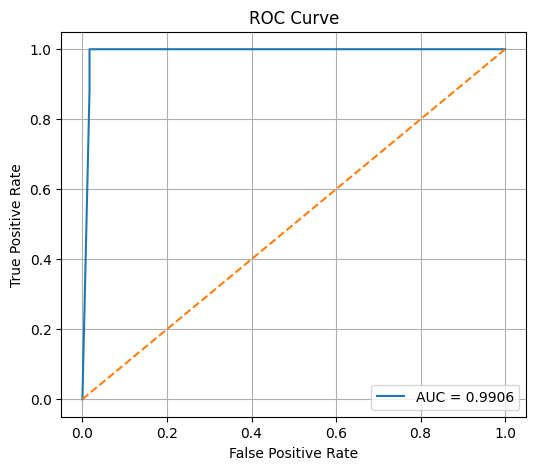

Optimal Threshold: 0.9998044

Classification Report (Optimal Threshold):
               precision    recall  f1-score   support

    fractured     1.0000    0.9832    0.9915       238
not fractured     0.9850    1.0000    0.9924       262

     accuracy                         0.9920       500
    macro avg     0.9925    0.9916    0.9920       500
 weighted avg     0.9921    0.9920    0.9920       500



In [ ]:
# ===============================
# IMPORT LIBRARY
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ===============================
# 1. TEST DATA GENERATOR
# ===============================
test_datagen = ImageDataGenerator(
    preprocessing_function=convnext_preprocess
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    shuffle=False  # WAJIB agar urutan label benar
)

# ===============================
# 2. CLASS LABELS
# ===============================
class_labels = list(test_gen.class_indices.keys())
class_labels = [class_labels[i] for i in sorted(test_gen.class_indices.values())]

print("Class Labels:", class_labels)

# ===============================
# 3. PREDIKSI MODEL (PROBABILITAS)
# ===============================
y_prob = model.predict(
    test_gen,
    steps=len(test_gen),
    verbose=1
).ravel()  # shape (N,)

# ===============================
# 4. KONVERSI PROBABILITAS → LABEL
# ===============================
THRESHOLD = 0.5  # standar binary classification

y_pred = (y_prob >= THRESHOLD).astype(int)
y_true = test_gen.classes

# Debug cepat (opsional)
print("Unique predictions:", np.unique(y_pred, return_counts=True))

# ===============================
# 5. METRIK EVALUASI GLOBAL
# ===============================
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score":  [accuracy, precision, recall, f1]
})

print("\nOverall Evaluation Metrics:")
display(metrics_df)

# ===============================
# 6. CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_labels,
        digits=4
    )
)

# ===============================
# 7. CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ===============================
# 8. ROC CURVE & AUC
# ===============================
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ===============================
# 9. (OPSIONAL) THRESHOLD OPTIMAL
# ===============================
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)

# Prediksi ulang dengan threshold optimal
y_pred_opt = (y_prob >= optimal_threshold).astype(int)

print("\nClassification Report (Optimal Threshold):")
print(
    classification_report(
        y_true,
        y_pred_opt,
        target_names=class_labels,
        digits=4
    )
)

Class indices : {'fractured': 0, 'not fractured': 1}


Saving 9-rotated3-rotated2.jpg to 9-rotated3-rotated2 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Raw model output : 1.1193021e-11
Predicted index  : 0


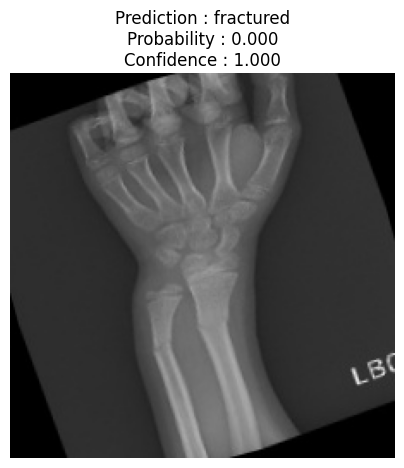

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_933']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


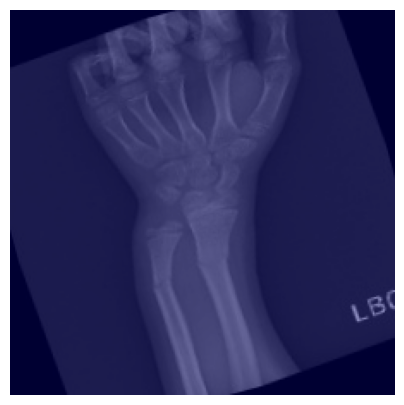

In [ ]:
# ================================
# IMPORT
# ================================
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# ================================
# PREPROCESSING (SAMA DENGAN TRAINING)
# ================================
def preprocess_image(img_path, target_size=(224,224)):

    img = Image.open(img_path).convert('RGB')
    img = img.resize(target_size)

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = convnext_preprocess(img_array)

    return img_array

# ================================
# PREDICTION FUNCTION
# ================================
def predict_image_class(model, img_array, class_indices):

    prob = model.predict(img_array)[0][0]

    # mapping index ke label
    index_to_class = {v:k for k,v in class_indices.items()}

    if prob >= 0.5:
        predicted_index = 1
    else:
        predicted_index = 0

    predicted_class = index_to_class[predicted_index]

    confidence = prob if predicted_index==1 else 1-prob

    print("Raw model output :", prob)
    print("Predicted index  :", predicted_index)

    return predicted_class, confidence, prob

# ================================
# GRAD CAM
# ================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:,0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap,0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()

# ================================
# DISPLAY GRADCAM
# ================================
def display_gradcam(img_path, heatmap, alpha=0.4):

    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize(img.size)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=alpha)
    plt.axis('off')
    plt.show()

# ================================
# LIHAT LABEL DATASET
# ================================
print("Class indices :", train_gen.class_indices)

# ================================
# INFERENCE
# ================================
uploaded = files.upload()

for fn in uploaded.keys():

    img_path = fn

    img_array = preprocess_image(img_path)

    predicted_class, confidence, prob = predict_image_class(
        model,
        img_array,
        train_gen.class_indices
    )

    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))

    plt.figure(figsize=(5,5))
    plt.imshow(img)

    plt.title(
        f"Prediction : {predicted_class}\n"
        f"Probability : {prob:.3f}\n"
        f"Confidence : {confidence:.3f}"
    )

    plt.axis('off')
    plt.show()

    # last conv layer
    last_conv_layer_name = [
        layer.name for layer in model.layers
        if isinstance(layer, tf.keras.layers.Conv2D)
    ][-1]

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    display_gradcam(img_path, heatmap)

Class indices : {'fractured': 0, 'not fractured': 1}


Saving 9-rotated3-rotated3-rotated2.jpg to 9-rotated3-rotated3-rotated2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Raw model output : 1.0
Predicted index  : 1


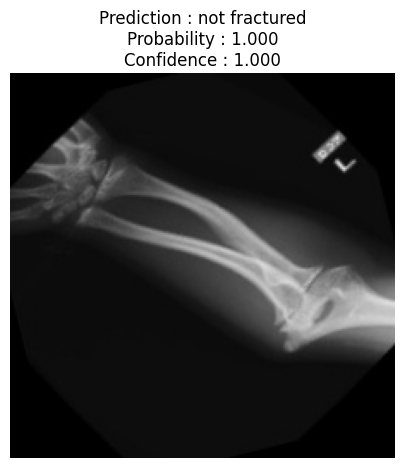

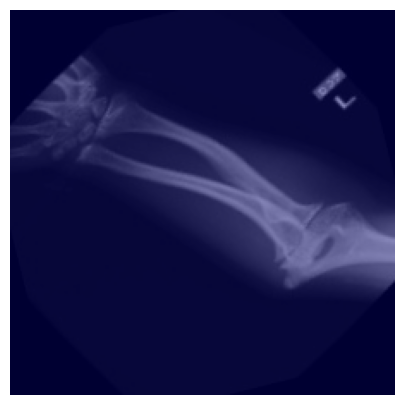

In [ ]:
# ================================
# IMPORT
# ================================
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# ================================
# PREPROCESSING (SAMA DENGAN TRAINING)
# ================================
def preprocess_image(img_path, target_size=(224,224)):

    img = Image.open(img_path).convert('RGB')
    img = img.resize(target_size)

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = convnext_preprocess(img_array)

    return img_array

# ================================
# PREDICTION FUNCTION
# ================================
def predict_image_class(model, img_array, class_indices):

    prob = model.predict(img_array)[0][0]

    # mapping index ke label
    index_to_class = {v:k for k,v in class_indices.items()}

    if prob >= 0.5:
        predicted_index = 1
    else:
        predicted_index = 0

    predicted_class = index_to_class[predicted_index]

    confidence = prob if predicted_index==1 else 1-prob

    print("Raw model output :", prob)
    print("Predicted index  :", predicted_index)

    return predicted_class, confidence, prob

# ================================
# GRAD CAM
# ================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:,0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap,0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()

# ================================
# DISPLAY GRADCAM
# ================================
def display_gradcam(img_path, heatmap, alpha=0.4):

    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize(img.size)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=alpha)
    plt.axis('off')
    plt.show()

# ================================
# LIHAT LABEL DATASET
# ================================
print("Class indices :", train_gen.class_indices)

# ================================
# INFERENCE
# ================================
uploaded = files.upload()

for fn in uploaded.keys():

    img_path = fn

    img_array = preprocess_image(img_path)

    predicted_class, confidence, prob = predict_image_class(
        model,
        img_array,
        train_gen.class_indices
    )

    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))

    plt.figure(figsize=(5,5))
    plt.imshow(img)

    plt.title(
        f"Prediction : {predicted_class}\n"
        f"Probability : {prob:.3f}\n"
        f"Confidence : {confidence:.3f}"
    )

    plt.axis('off')
    plt.show()

    # last conv layer
    last_conv_layer_name = [
        layer.name for layer in model.layers
        if isinstance(layer, tf.keras.layers.Conv2D)
    ][-1]

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    display_gradcam(img_path, heatmap)